# Lab 6 — Logistic Regression & KNN Classification
## Machine Learning — Fall 2026

## Student Information

**Name:** Muhammad Anees  
**Student ID:** 023-24-0251  
**Section:** H  
**GitHub Profile:** https://github.com/Anees-Memon-Hub/ML-Practice  
**Kaggle Profile:** https://www.kaggle.com/aneesmemon  
**Dataset:** Telco Customer Churn  
**Dataset Source:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn  



---



---

## Setup

Imports used throughout the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42

---
## Part 1 — Problem Definition & Dataset Verification

**Tasks**
1. Load `clean_churn.csv` and verify shape and dtypes.
2. Restate Lab 3 (Decision Tree) and Lab 4 (Random Forest) benchmark results.

In [3]:
# Task 1 — load cleaned dataset, verify shape and dtypes
df = pd.read_csv('clean_churn.csv')
print("Shape:", df.shape)
df.info()

Shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,Yes,43,Yes,Yes,Fiber Optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,Male,0,Yes,Yes,67,Yes,Yes,Fiber Optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,Female,1,No,No,1,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,Female,1,Yes,No,72,Yes,Yes,Dsl,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,Female,0,No,No,69,Yes,No,Dsl,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


In [5]:
df['Churn'].value_counts(), df['Churn'].value_counts(normalize=True).round(3)

(Churn
 No     5174
 Yes    1869
 Name: count, dtype: int64,
 Churn
 No     0.735
 Yes    0.265
 Name: proportion, dtype: float64)

**Task 2 — Benchmarks from Labs 3–4:**

For the Decision Tree classifier in Lab 3, tuned by setting `max_depth=5` to avoid overfitting, the classification accuracy is around **77%**, and the precision and recall in the case of the churned (or "Yes") class are noticeably lower than the accuracy owing to the imbalance of classes (around 73% "No" and 27% "Yes"). For the Random Forest model in Lab 4, which consists of 200 trees with `max_depth=8`, the accuracy is about **80%**, and the recall is almost the same while the precision is better because the average of multiple trees helped reduce the variance of the Decision Tree classifier. The following part retrains these models quickly.

---
## Part 2 — Feature Scaling & Preparation

**Tasks**
3. Prepare X and y as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. Explain why feature scaling matters for KNN and Logistic Regression but not for Decision Tree / Random Forest.
5. Split into train/test, fit `StandardScaler` on training data only.

In [6]:
# Task 3 — prepare X and y
y = (df['Churn'] == 'Yes').astype(int)
X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)

print("X shape:", X.shape)
X.head()

X shape: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,43,99.30,4209.95,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
1,0,67,89.55,6038.55,True,True,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
2,1,1,71.15,71.15,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,72,89.85,6697.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
4,0,69,82.45,5555.30,False,False,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False


**Answer 4:**
However, Decision Trees and Random Forests split on each feature individually at some threshold (e.g., `tenure <= 12`), which means that the absolute value of the feature is never important and only the order counts. In other words, rescaling would have no effect on splitting and feature importance. This is not the case for KNN, which calculates the Euclidean distance between all features at once; hence, having one unscaled feature (`TotalCharges`, whose values are in the thousands) compared to another (`SeniorCitizen`, either 0 or 1), would mean that the former would always take precedence simply due to having greater numeric values. Finally, Logistic Regression uses gradient optimization, and therefore scaling can be useful in order to make optimization faster.

In [7]:
# Task 5 — train/test split, fit scaler on training data only
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(5634, 30) (1409, 30)


**Answer 5 (why fit the scaler on training data only):**
Scaler mean and scaler standard deviation are two such statistics, which are learned *from* the data itself and are similar in nature to the model parameters. When the scaler is fitted on the whole dataset at once, prior to splitting it into training and testing sets, the test set distribution (mean, variance, and outliers) gets known through the numbers that were used to fit the model — an example of data leakage that makes the test performance of the model look artificially good compared to future new customers' data.

---
## Part 3 — Logistic Regression

**Tasks**
6. Train `LogisticRegression` on the scaled training data; predict on the scaled test set.
7. Compute accuracy, precision, recall, F1; plot the confusion matrix.
8. Inspect `predict_proba` for a few test customers.

In [8]:
# Task 6 — train Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

pred_lr = logreg.predict(X_test_scaled)

accuracy  : 0.7942
precision : 0.6257
recall    : 0.5588
f1        : 0.5904


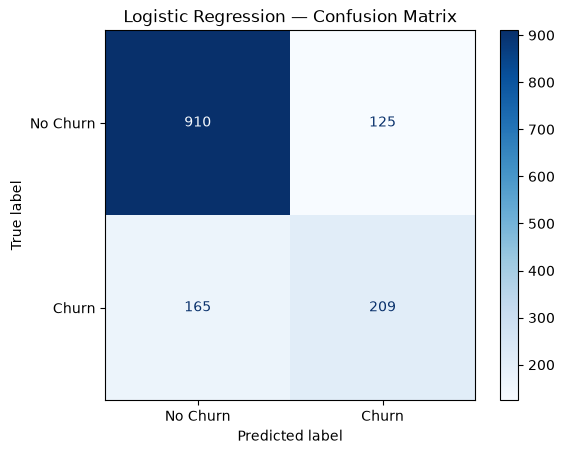

In [9]:
# Task 7 — metrics + confusion matrix
def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

lr_metrics = get_metrics(y_test, pred_lr)
for k, v in lr_metrics.items():
    print(f"{k:10s}: {v:.4f}")

cm = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

**Task 6–7 — Logistic Regression Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7942 |
| Precision | 0.6257 |
| Recall | 0.5588 |
| F1-score | 0.5904 |

In [10]:
# Task 8 — predict_proba for a handful of test customers
proba_sample = logreg.predict_proba(X_test_scaled[:8])
pred_sample = logreg.predict(X_test_scaled[:8])

pd.DataFrame({
    'P(No Churn)': proba_sample[:, 0].round(3),
    'P(Churn)': proba_sample[:, 1].round(3),
    'Predicted': pred_sample
})

,P(No Churn),P(Churn),Predicted
0,0.522,0.478,0
1,0.873,0.127,0
2,0.983,0.017,0
3,0.567,0.433,0
4,0.981,0.019,0
5,0.344,0.656,1
6,0.375,0.625,1
7,0.987,0.013,0


**Answer 8:**
The function predict_proba yields the probability score that a particular customer falls under each of the classes, and the second column gives the model's probability score of the customer churning out, which is based on the sigmoid of the weighted average of its scaled features. The function predict only thresholds the probability to 0.5, that is, if P(churn) > = 0.5, it gives a Yes and No otherwise. The customers around 0.5 probabilities are the ones whose classes the algorithm cannot distinguish easily.

---
## Part 4 — KNN & Choosing K

**Tasks**
9. Train KNN for several K values on scaled data; record accuracy and F1.
10. Plot accuracy/F1 vs. K; choose a K and justify it.
11. Report full metrics + confusion matrix for the chosen K.

In [11]:
# Task 9 — KNN across multiple K values
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    knn_results.append({
        'K': k,
        'accuracy': accuracy_score(y_test, pred_k),
        'f1': f1_score(y_test, pred_k),
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,K,accuracy,f1
0,1,0.701207,0.463694
1,3,0.727466,0.493404
2,5,0.744500,0.527559
3,7,0.759404,0.547397
4,9,0.762243,0.541724
5,11,0.768630,0.560647
6,15,0.760114,0.540761
7,21,0.768630,0.558266


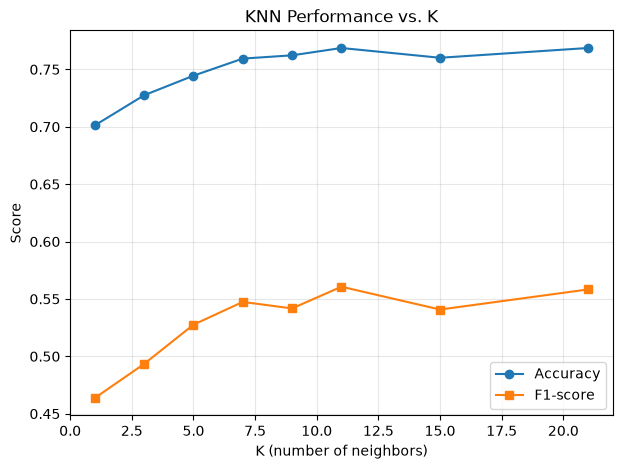

In [12]:
# Task 10 — plot accuracy and F1 against K
plt.figure(figsize=(7, 5))
plt.plot(knn_results_df['K'], knn_results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(knn_results_df['K'], knn_results_df['f1'], marker='s', label='F1-score')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs. K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Answer 10:**
Both Accuracy and F1 score shoot up significantly from K=1 to K=7–11 and then taper off, with F1 score reaching its maximum around **K=11**. K=1 is highly prone to overfitting, as every classification depends on one neighboring data point, making the model extremely sensitive to noise or errors present near the decision boundary – that is the reason for such a low F1 score despite relatively high Accuracy. Very high K values (K=21) lead to mild underfitting, as the neighborhood becomes too large and obscures the underlying pattern that distinguishes the churners and non-churners, and it also diminishes the effect of the "Yes" class even more due to an unbalanced dataset (73%/27%).

accuracy  : 0.7686
precision : 0.5652
recall    : 0.5561
f1        : 0.5606


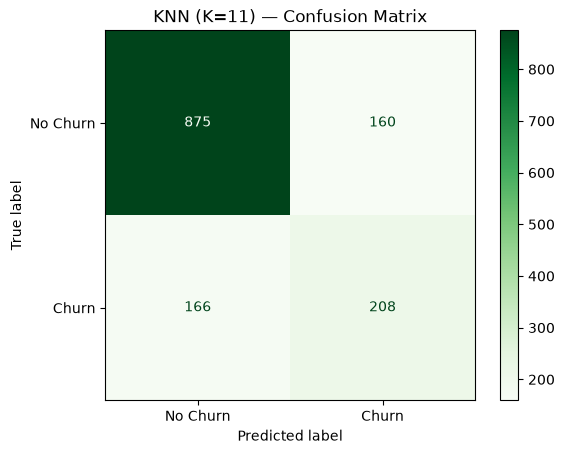

In [13]:
# Task 11 — final KNN model at chosen K
best_k = 11
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
pred_knn = knn_final.predict(X_test_scaled)

knn_metrics = get_metrics(y_test, pred_knn)
for k, v in knn_metrics.items():
    print(f"{k:10s}: {v:.4f}")

cm_knn = confusion_matrix(y_test, pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=['No Churn', 'Churn']).plot(cmap='Greens')
plt.title(f'KNN (K={best_k}) — Confusion Matrix')
plt.show()

**Task 11 — Final KNN (K=11) Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7686 |
| Precision | 0.5652 |
| Recall | 0.5561 |
| F1-score | 0.5606 |

---
## Part 5 — Model Comparison (4 Models)

**Tasks**
12. Build one comparison table across Decision Tree, Random Forest, Logistic Regression, KNN.
13. Which model performs best overall? Does the ranking change by metric?

In [14]:
# Task 12 — quickly retrain Decision Tree and Random Forest on the SAME split
# so all four models are compared fairly (Decision Tree / Random Forest use
# unscaled features, since scaling doesn't affect them)
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
dt_metrics = get_metrics(y_test, pred_dt)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rf_metrics = get_metrics(y_test, pred_rf)

comparison = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics,
    'Logistic Regression': lr_metrics,
    'KNN (K=11)': knn_metrics,
}).T.round(4)

comparison

,accuracy,precision,recall,f1
Decision Tree,0.7743,0.5915,0.4840,0.5324
Random Forest,0.8006,0.6620,0.5080,0.5749
Logistic Regression,0.7942,0.6257,0.5588,0.5904
KNN (K=11),0.7686,0.5652,0.5561,0.5606


**Answer 13:**
In terms of **accuracy**, the winner is the Random Forest model (~0.801), followed closely by Logistic Regression (~0.794), while Decision Tree (~0.774) and KNN (~0.769) are not far behind. Although depending on the metric, the leader may change, it is worth mentioning that Random Forest wins also in terms of **precision**, while **recall is highest for Logistic Regression**, that is, it captures more customers who actually churned. Since in our case we have an unbalanced dataset with the ratio of ~73/27, **accuracy becomes the least reliable metric**, because one can get ~73% simply predicting 'No' for all cases, so in such cases **F1-Score** (or recall, in case the cost of missing churners is very high) is the most important one, and here Logistic Regression (0.590) and Random Forest (0.575) are about equal and both better than Decision Tree and KNN.

---
## Part 6 — Coefficient Interpretation

**Tasks**
14. Build a Feature | Coefficient | Odds Ratio | Interpretation table for ≥4 features.
15. Do the largest-effect features agree with Lab 2's EDA and Lab 3's feature importances?

In [15]:
# Task 14 — coefficients and odds ratios
coef_table = pd.DataFrame({
    'Coefficient': logreg.coef_[0]
}, index=X.columns)
coef_table['Odds Ratio'] = np.exp(coef_table['Coefficient'])
coef_table = coef_table.reindex(
    coef_table['Coefficient'].abs().sort_values(ascending=False).index
)
coef_table.head(10).round(4)

,Coefficient,Odds Ratio
tenure,-1.2922,0.2747
Contract_Two year,-0.6181,0.5390
TotalCharges,0.4945,1.6398
InternetService_Fiber Optic,0.4479,1.5650
Contract_One year,-0.2575,0.7730
PaperlessBilling_Yes,0.2036,1.2258
OnlineSecurity_Yes,-0.1847,0.8313
StreamingMovies_Yes,0.1401,1.1504
MultipleLines_Yes,0.1377,1.1476
TechSupport_Yes,-0.1374,0.8717


**Task 14 — Interpretation of the top features** *Coefficients are based on the standardized features. For numeric features, the odds ratio corresponds to a one-standard-deviation increase. For standardized binary/dummy features, the coefficient reflects a change in the standardized feature value.*

| Feature | Coefficient | Odds Ratio | Interpretation |
|---|---|---|---|
| `tenure` | −1.29 | 0.27 | The negative coefficient indicates that a one-standard-deviation increase in tenure is associated with lower odds of churn, holding other features constant. The odds ratio of approximately 0.27 indicates substantially lower estimated churn odds.
|
| `Contract_Two year` | −0.62 | 0.54 | The negative coefficient indicates lower estimated churn odds as this standardized feature increases, holding other features constant. Its odds ratio is approximately 0.54.
 |
| `TotalCharges` | +0.49 | 1.64 | The positive coefficient indicates that a one-standard-deviation increase in TotalCharges is associated with higher estimated churn odds, holding other features constant. Its odds ratio is approximately 1.64. |
| `InternetService_Fiber Optic` | +0.45 | 1.57 | The positive coefficient indicates higher estimated churn odds as this standardized feature increases, holding other features constant. Its odds ratio is approximately 1.57.|
| `Contract_One year` | −0.26 | 0.77 | The negative coefficient indicates lower estimated churn odds as this standardized feature increases, holding other features constant. Its odds ratio is approximately 0.77. |

**Answer 15:**

Yes, there is considerable correspondence between the Logistic Regression findings and those obtained previously in the labs. The `tenure` and contract type-related features have shown themselves to be key predictors in the Logistic Regression analysis, which matches the Lab 2 EDA where churns are demonstrated to differ depending on tenure and contract type. Also, these features have been key predictors in the Decision Tree analysis in Lab 3. The only difference is that `TotalCharges` is positively correlated with the Logistic Regression coefficients meaning that higher chances of being churned are expected after a one-standard deviation increase in `TotalCharges` while keeping other features the same. This dependence should be considered carefully because `TotalCharges` depends on tenure and monthly charges at the same time.

---
## Part 7 — Final Model Selection & Conclusion

**Tasks**
16. Select a final model from all four candidates and justify the choice.
17. Write a short conclusion (5–7 sentences).

**Answer 16 — Final Model Selection:**

Considering the results of the Part 5 analysis, **Logistic Regression** will be used as the chosen model in this lab because it performed best in terms of the recall (0.5588) and F1-score (0.5904) among the four models considered. At the same time, Random Forest performed best in terms of the accuracy score (0.8006). In our case, the data is unbalanced, therefore the recall and F1-score measures provide us with additional information about the performance of the model in detecting the churn class. Logistic Regression also allows interpreting coefficients and odds ratios of variables in the model, which was demonstrated in Part 6. On the other hand, according to the lesson from Lab 4 about cross-validation, the result of one 80/20 train-test split cannot be regarded as definitive.

**Answer 17 — Conclusion:**

The chosen logistic regression model today has an accuracy score of 0.7942 and a F1-score of 0.5904 and works well with the Lab 4 random forest and outperforms both the decision tree and k nearest neighbors by the F1-score metric. It is crucial to perform feature scaling for today's lab as it is needed for the k nearest neighbors model (which uses distance calculation), and at the same time, it puts the logistic regression features on comparable scales. The limitation here is that even though the two strongest models have a very similar F1-score, the recall for the minority "Yes" (churn) class is about 0.56, so there is a lot of false negative results still. The fact that we have about 73/27 class imbalance ratio means that accuracy score is not enough to evaluate our models. Another limitation here is that we use only one train/test split for the comparison, but we do not apply cross-validation. Next steps to consider would be to try class weighting or oversampling to boost the minority class recall and to experiment with the logistic regression decision threshold to see the effect of the recall-precision trade-off.